In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Part 1: Determine k in K-Means Clustering

In [7]:
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

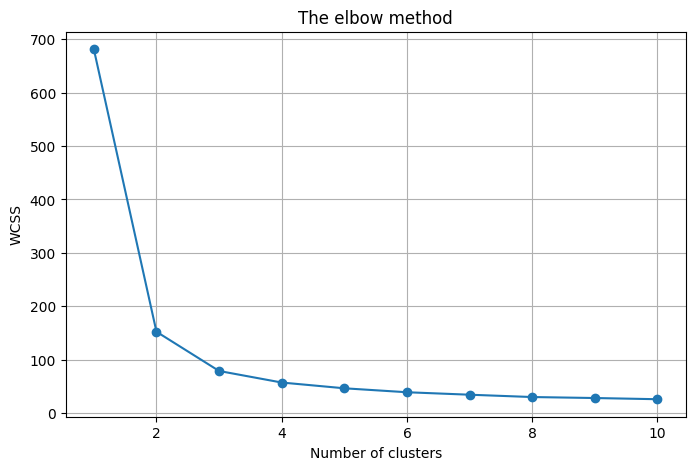

In [8]:
X_iris = iris.data
wcss = []
# Testing k values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_iris)
    wcss.append(kmeans.inertia_)

# Plotting the results onto a line graph to observe 'The Elbow'
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') # kmeans.inertia_
plt.grid(True)
plt.show()

### Part 2: PCA for Logistic Regression (MNIST)

In [9]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
print("Running Logistic Regression without PCA...")
lr_original = LogisticRegression(solver='lbfgs', max_iter=1000)
start_time = time.time()
lr_original.fit(X_train, y_train)
end_time = time.time()

Running Logistic Regression without PCA...


In [13]:
no_pca_time = end_time - start_time
no_pca_acc = accuracy_score(y_test, lr_original.predict(X_test))

In [14]:
no_pca_acc

0.9155714285714286

In [15]:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Number of components chosen by PCA: {pca.n_components_}")

print("Running Logistic Regression with PCA...")
lr_pca = LogisticRegression(solver='lbfgs', max_iter=1000)
start_time = time.time()
lr_pca.fit(X_train_pca, y_train)
end_time = time.time()

pca_time = end_time - start_time
pca_acc = accuracy_score(y_test, lr_pca.predict(X_test_pca))

Number of components chosen by PCA: 330
Running Logistic Regression with PCA...


In [16]:
print("\n--- Results Comparison ---")
print(f"Without PCA - Time: {no_pca_time:.2f}s, Accuracy: {no_pca_acc:.4f}")
print(f"With PCA    - Time: {pca_time:.2f}s, Accuracy: {pca_acc:.4f}")
print(f"Speedup factor: {no_pca_time / pca_time:.2f}x")


--- Results Comparison ---
Without PCA - Time: 4.07s, Accuracy: 0.9156
With PCA    - Time: 3.25s, Accuracy: 0.9219
Speedup factor: 1.25x
